In [1]:
import numpy as np
import importlib
import regulator

In [2]:
!python --version

/bin/bash: line 1: python: command not found


In [3]:
from importlib import reload
import my_dataclasses
reload(my_dataclasses)
import my_dataclasses

In [4]:
import flowNLO
reload(flowNLO)
import flowNLO

from flowNLO import FlowNLO

In [5]:
N_p=100
p_min=0.01
p_max=100.
N_w=100
w_min=0.01
w_max=100.
params_grid_external=my_dataclasses.Params_grid_external(N_p=N_p, p_min=p_min, p_max=p_max,
                                                        N_w=N_w, w_min=w_min, w_max=w_max)

In [6]:
params_grid_internal=my_dataclasses.Params_grid_internal(deg_q=500, q_max=10)

In [7]:
approximation="NLO"
dim=1
ds=0.02
f_in = np.ones((N_p,N_w))
IC = my_dataclasses.IC_NLO(g_in=1., eta_D_in=0., eta_nu_in=0., f_D_in=f_in, f_nu_in=f_in, f_lambda_in=f_in)
r  = lambda x : regulator.exp1(x, 1, 1)
r_ = lambda x : regulator.exp1_(x, 1, 1)
coeff_nu =1
version_Ak="1"
path_save='test'
save_spl=False

In [8]:
flow = FlowNLO(approximation=approximation,dim=dim,
            params_grid_external=params_grid_external,
            params_grid_internal=params_grid_internal,
            ds=ds, IC=IC,
            r=r,r_=r_, 
            version_Ak = version_Ak,
			path_save=path_save, save_spl=save_spl)

1D versions are used: theta = [0.         3.14159265] wtheta = [1 1]
1D: vdim1 = 1 Jdim1 = 1
1D: self.sin_d2_broad = 1
=== Initialized with the following parameters: ===
approximation=NLO
dim=1
version_Ak=1
p_min=0.01
p_max=100.0
Np=100
Nw=100
w_min=0.01
w_max=100.0
q_max=10
degtheta=2
save_spl=False
ds=0.02


In [9]:
flow.f_spline_update() 

f_spline_update_LO
f_spline_update_NLO


In [10]:
import matplotlib.pyplot as plt

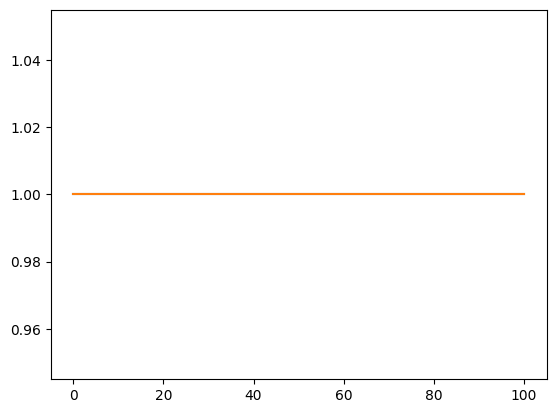

In [11]:
plt.plot(flow.p,flow.f_nu[:,0])
plt.plot(flow.p,flow.f_nu_spl[0](flow.p))

In [12]:
flow.Is_update() 

f_spline_update_NLO


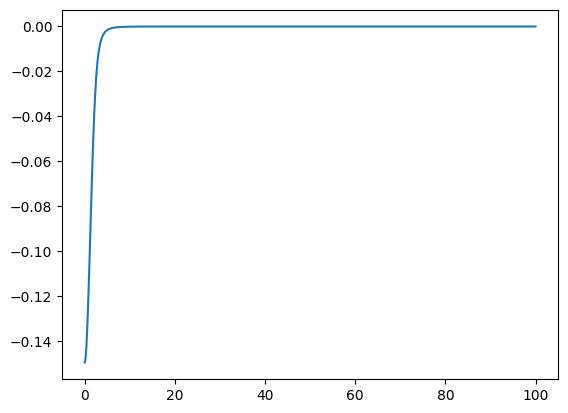

In [13]:
plt.plot(flow.p,flow.Is_D[:,0])

In [14]:
flow.eta_update() 

In [15]:
flow.eta_D,flow.eta_nu

(np.float64(0.14149934942004086), np.float64(0.14149934942004083))

In [16]:
flow.g

1.0

In [17]:
flow.g_update() 

In [18]:
flow.g

np.float64(1.0143400260231983)

In [19]:
flow.f_update() 

f_spline_update_NLO


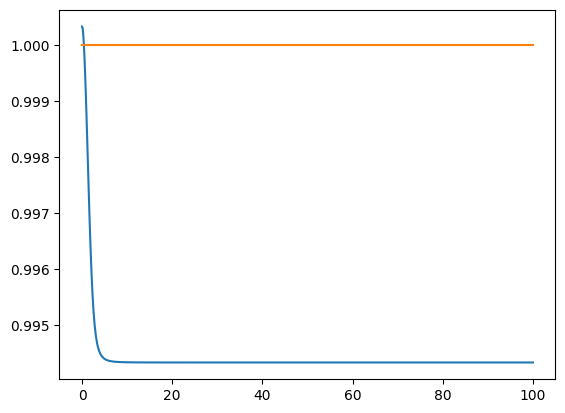

In [20]:
plt.plot(flow.p,flow.f_nu[:,0])
plt.plot(flow.p,flow.f_nu_spl[0](flow.p))

In [21]:
flow.f_spline_update() 

f_spline_update_LO
f_spline_update_NLO


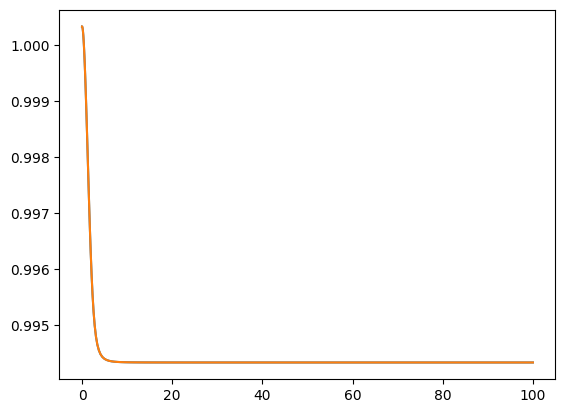

In [22]:
plt.plot(flow.p,flow.f_nu[:,0])
plt.plot(flow.p,flow.f_nu_spl[0](flow.p))

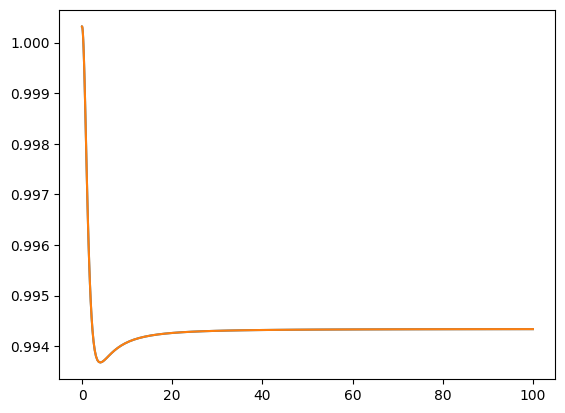

In [28]:
plt.plot(flow.w,flow.f_nu[20,:])
plt.plot(flow.w,flow.f_nu_spl_w[20](flow.w))